Name: Lama Alfreah.

# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex2_multi-reg.ipynb)

In [2]:
import pandas as pd
import sklearn

## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [15]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
auto_mpg = fetch_ucirepo(id=9) 

### Step 2.a Assign variables `X` to the features and `y` to the target

In [5]:
# data (as pandas dataframes) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 

### Step 2.b print the type of each

In [23]:
display(X .dtypes)
display(y .dtypes)

displacement    float64
cylinders         int64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
dtype: object

mpg    float64
dtype: object

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

Numerical & the task is regression.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [24]:
X.shape
X.head()    

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [27]:
display(X[['displacement', 'horsepower', 'weight', 'acceleration']].describe())
display(X[['cylinders', 'model_year', 'origin']].astype('str').describe())

,displacement,horsepower,weight,acceleration
count,398.000000,392.000000,398.000000,398.000000
mean,193.425879,104.469388,2970.424623,15.568090
std,104.269838,38.491160,846.841774,2.757689
min,68.000000,46.000000,1613.000000,8.000000
25%,104.250000,75.000000,2223.750000,13.825000
50%,148.500000,93.500000,2803.500000,15.500000
75%,262.000000,126.000000,3608.000000,17.175000
max,455.000000,230.000000,5140.000000,24.800000


,cylinders,model_year,origin
count,398,398,398
unique,5,13,3
top,4,73,1
freq,204,40,249


### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

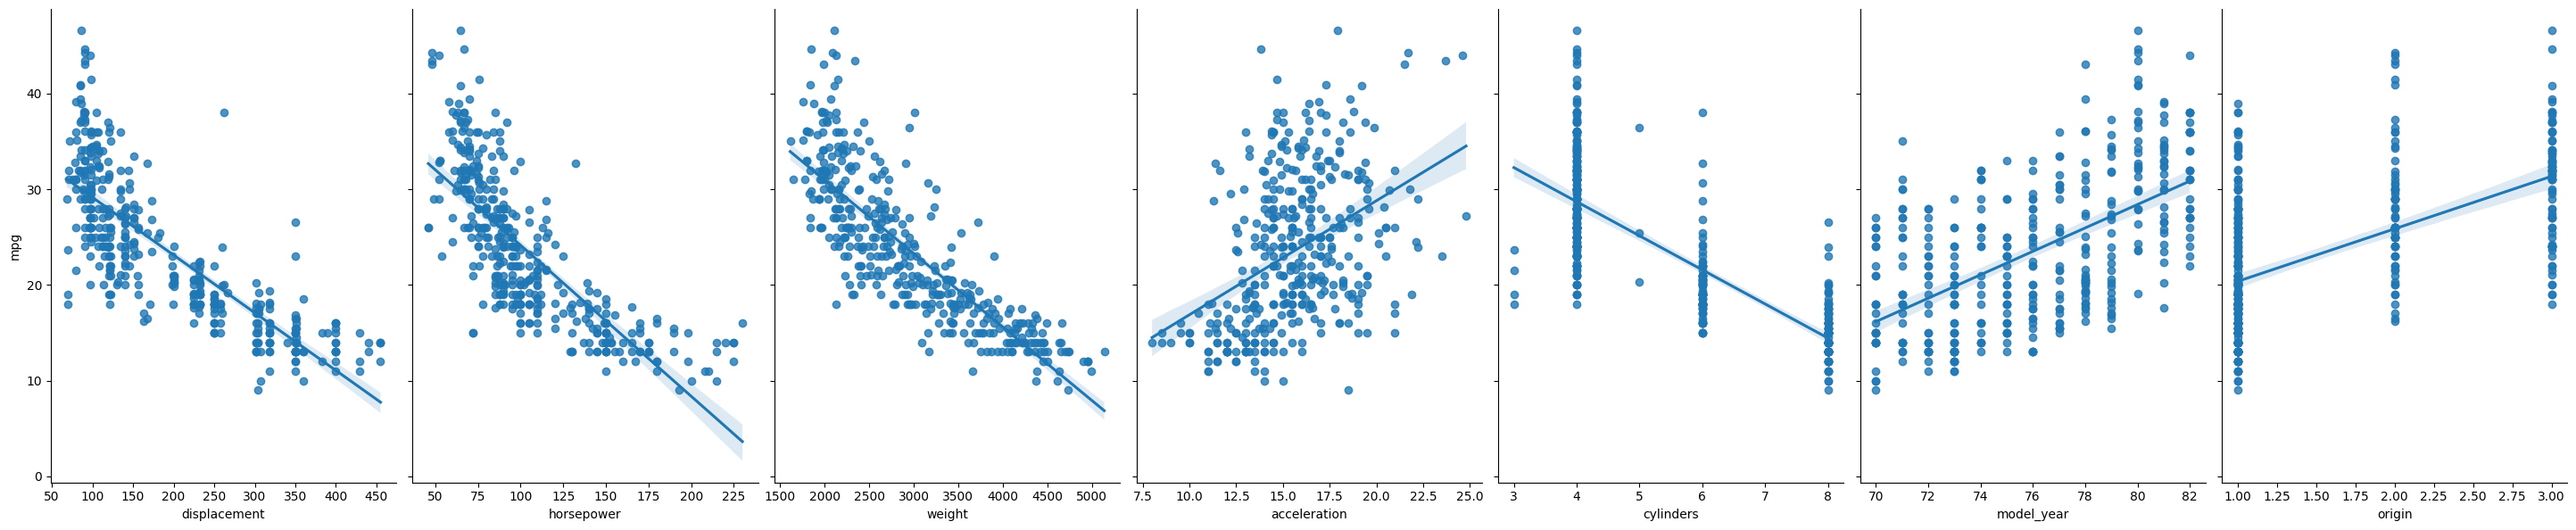

In [36]:
import seaborn as sns
df = X.copy()
df['mpg']=y
sns.pairplot(
    df, 
    x_vars=['displacement', 'horsepower', 'weight', 'acceleration', 'cylinders','model_year','origin' ], 
    y_vars='mpg', 
    height=6, 
    aspect=0.7, 
    kind='reg'
    )

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

1. `x=cylinders` and `y=mpg` > dec
2. `x=displacement` and `y=mpg` > dec
3. `x=horsepower` and `y=mpg`> dec
4. `x=weight` and `y=mpg` > dec
5. `x=acceleration` and `y=mpg` > inc

### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [39]:
from sklearn.pipeline import Pipeline
pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]
)

### Step 8. Split the dataset into train and test sets

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 9.a Fit the pipeline on the training set

In [41]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If 

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [44]:
model = pipe.named_steps["model"]
print(model.coef_)
print(model.intercept_)

[[ 1.44180107 -0.25990572 -0.44238237 -5.68369444  0.20472569  2.86474299
   1.06517559]]
[23.6081761]


### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

The coefficient for weight is negative, so decreasing the weight increases mpg. However, because the feature was standardized, the coefficient reflects the effect per one standard deviation change in weight, not per 1 kg directly.

### Step 10. Evaluate the pipeline on the test set

In [46]:
score = pipe.score(X_test, y_test)
print(score)

0.8475695460782323
